In [126]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [127]:
X, y = make_classification(
    n_features=10,
    n_samples=10000,
    n_informative=8,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Logistic Regression

In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
model =    LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.74      0.71      0.72      1007
           1       0.72      0.74      0.73       993

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000



In [129]:
 probabilities = model.predict_proba(X_test)[:, 1] #This [:, 1] will return all the 1th index from each item
 probabilities

array([0.48247163, 0.85837172, 0.71963266, ..., 0.70875292, 0.57679944,
       0.57221753], shape=(2000,))

# Assuming that it is an healthcare dataset(for Pneumonia disease). In that case we need to maximize the Recall of positive class(1)

In [130]:
y_pred_new  = (probabilities >.4).astype(int)
report = classification_report(y_test, y_pred_new)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.61      0.70      1007
           1       0.68      0.86      0.76       993

    accuracy                           0.73      2000
   macro avg       0.75      0.73      0.73      2000
weighted avg       0.75      0.73      0.73      2000



In [131]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, threshold =  roc_curve(y_test, probabilities)

# Now for gaining Recall value at-least 90%, we need to search for TPR value of .90 or near. Then find the threshold value with the same TPR value index

In [132]:
tpr

array([0.        , 0.00100705, 0.02114804, 0.02114804, 0.02215509,
       0.02215509, 0.02618328, 0.02618328, 0.02719033, 0.02719033,
       0.04028197, 0.04028197, 0.04330312, 0.04330312, 0.05438066,
       0.05438066, 0.05840886, 0.05840886, 0.06344411, 0.06344411,
       0.06545821, 0.06545821, 0.08257805, 0.08257805, 0.09164149,
       0.09164149, 0.09264854, 0.09264854, 0.09365559, 0.09365559,
       0.09466264, 0.09466264, 0.10171198, 0.10171198, 0.10271903,
       0.10271903, 0.10674723, 0.10674723, 0.10775428, 0.10775428,
       0.11077543, 0.11077543, 0.11379658, 0.11379658, 0.12084592,
       0.12084592, 0.12386707, 0.12386707, 0.13091641, 0.13091641,
       0.13192346, 0.13192346, 0.13595166, 0.13595166, 0.13897281,
       0.13897281, 0.14098691, 0.14098691, 0.14602216, 0.14602216,
       0.1490433 , 0.1490433 , 0.15609265, 0.15609265, 0.1591138 ,
       0.1591138 , 0.16012085, 0.16012085, 0.16213494, 0.16213494,
       0.16314199, 0.16314199, 0.17522659, 0.17522659, 0.17623

In [133]:
import numpy as np
desired_recall = .90
closest_index = np.argmin(abs(tpr- desired_recall))
print(closest_index)

600


# Now find the Threshold value by using that index

In [134]:
final_threshold = threshold[closest_index]
print(final_threshold)

0.3487209418608129


In [135]:
y_pred_new  = (probabilities > final_threshold).astype(int)
report = classification_report(y_test, y_pred_new)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.55      0.67      1007
           1       0.66      0.90      0.76       993

    accuracy                           0.72      2000
   macro avg       0.75      0.72      0.71      2000
weighted avg       0.75      0.72      0.71      2000



In [136]:
print(final_threshold, fpr[closest_index], tpr[closest_index])

0.3487209418608129 0.45084409136047665 0.8992950654582075


## Lets plot the ROC curve and calculate the AUC

In [137]:
area = auc(fpr, tpr)
area

0.8035533741153316

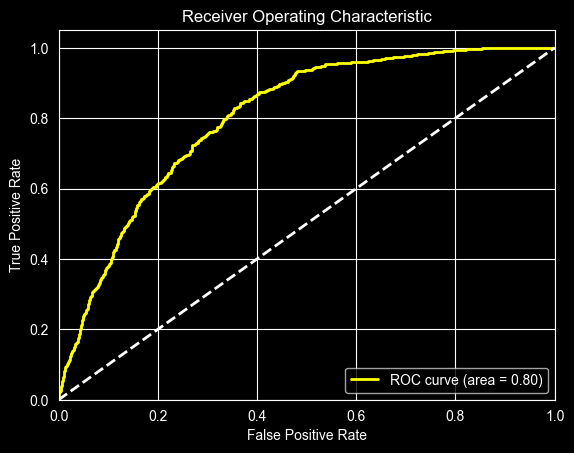

In [138]:
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='yellow', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='white', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Now train the dataset with XGBoost and then implement the ROC, AUC

In [139]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1007
           1       0.94      0.93      0.94       993

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [140]:
xg_prob = model.predict_proba(X_test)[:, 1]
y_pred_xg  = (xg_prob >.4).astype(int)
xg_report = classification_report(y_test, y_pred_new)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1007
           1       0.94      0.93      0.94       993

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [141]:
from sklearn.metrics import roc_curve, auc
xg_fpr, xg_tpr, xg_threshold =  roc_curve(y_test, xg_prob)
xg_area = auc(xg_fpr, xg_tpr)
print(xg_area)

0.980416040385979


In [142]:

desired_recall = .90
closest_index = np.argmin(abs(xg_tpr- desired_recall))
print(closest_index)

78


In [161]:
final_threshold = threshold[closest_index]
print(final_threshold, xg_fpr[closest_index], xg_tpr[closest_index])

0.8048792862579107 0.04568023833167825 0.9214501510574018


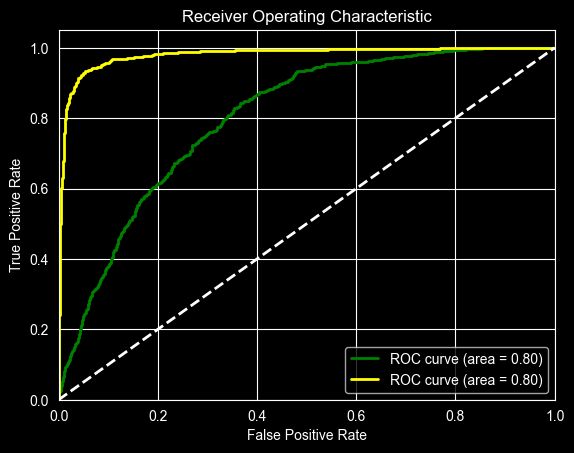

In [147]:
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='green', lw=2, label='ROC curve (area = %0.2f)' % area) # This is for Logistic Classifier
plt.plot(xg_fpr, xg_tpr, color='yellow', lw=2, label='ROC curve (area = %0.2f)' % area) # This is for XGBoost
plt.plot([0, 1], [0, 1], color='white', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [164]:
desired_recall = .90
closest_index = np.argmin(abs(xg_tpr- desired_recall))
print("Closest Index:", closest_index)

final_threshold = threshold[closest_index]
print("Threshold: ", final_threshold,"\nFalse Positive Rate: ", xg_fpr[closest_index],"\nTrue Positive Rate: ", xg_tpr[closest_index])

Closest Index: 78
Threshold:  0.8263478220303454 
False Positive Rate:  0.03574975173783516 
True Positive Rate:  0.8992950654582075
